# 基于机器学习的 Lorenz 混沌系统短期状态预测

本 Notebook 用 Lorenz 方程数值模拟生成数据，并完成数据处理、EDA、相关性热力图、StandardScaler 标准化、Baseline Model、随机森林主模型、MLP 可选模型、RMSE/MAE/R² 指标评价，以及真实值 vs 预测值散点图。


## 1. 导入依赖与全局设置

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIGURES_DIR = Path("figures")
RESULTS_DIR = Path("results")
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font="SimHei")
plt.rcParams["axes.unicode_minus"] = False

## 2. 生成 Lorenz 系统数据

Lorenz 系统方程为：

$$
\frac{dx}{dt}=\sigma(y-x),\quad
\frac{dy}{dt}=x(\rho-z)-y,\quad
\frac{dz}{dt}=xy-\beta z.
$$

本文采用经典参数 $\sigma=10, \rho=28, \beta=8/3$，并通过数值积分生成时间序列。

In [2]:
sigma = 10
rho = 28
beta = 8 / 3
initial_state = [1.0, 1.0, 1.0]
t_start, t_end = 0, 50
n_points = 10000
t_eval = np.linspace(t_start, t_end, n_points)

def lorenz_system(t, state, sigma=sigma, rho=rho, beta=beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

solution = solve_ivp(
    lorenz_system,
    (t_start, t_end),
    initial_state,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-12,
)

trajectory = pd.DataFrame({
    "time": solution.t,
    "x": solution.y[0],
    "y": solution.y[1],
    "z": solution.y[2],
})

trajectory.head()

,time,x,y,z
0,0.000000,1.000000,1.000000,1.000000
1,0.005001,1.003194,1.129853,0.992050
2,0.010001,1.012568,1.259946,0.984890
3,0.015002,1.027853,1.391089,0.978559
4,0.020002,1.048831,1.524054,0.973112


## 3. 构造监督学习数据集

为了让任务不过于简单，本文预测当前时刻之后 10 个采样步长的 $x$ 值。输入变量为当前状态 $x(t),y(t),z(t)$，预测目标为 $x(t+10\Delta t)$。


In [3]:
prediction_horizon = 10
supervised = pd.DataFrame({
    "x_t": trajectory["x"].iloc[:-prediction_horizon].to_numpy(),
    "y_t": trajectory["y"].iloc[:-prediction_horizon].to_numpy(),
    "z_t": trajectory["z"].iloc[:-prediction_horizon].to_numpy(),
    "x_next": trajectory["x"].iloc[prediction_horizon:].to_numpy(),
})

supervised.to_csv(RESULTS_DIR / "lorenz_supervised_dataset.csv", index=False)
print(f"数据集维度: {supervised.shape}")
supervised.head()

数据集维度: (9990, 4)


,x_t,y_t,z_t,x_next
0,1.000000,1.000000,1.000000,1.287610
1,1.003194,1.129853,0.992050,1.345925
2,1.012568,1.259946,0.984890,1.409649
3,1.027853,1.391089,0.978559,1.478892
4,1.048831,1.524054,0.973112,1.553798


## 4. 数据质量检查与描述统计

In [4]:
missing_values = supervised.isna().sum()
missing_values.to_csv(RESULTS_DIR / "missing_values.csv", header=["missing_count"])
print("各列缺失值数量：")
print(missing_values)

descriptive_stats = supervised.describe().T
selected_stats = descriptive_stats[["mean", "std", "min", "25%", "50%", "75%", "max"]]
selected_stats.to_csv(RESULTS_DIR / "descriptive_stats.csv")
selected_stats

各列缺失值数量：
x_t       0
y_t       0
z_t       0
x_next    0
dtype: int64


,mean,std,min,25%,50%,75%,max
x_t,-1.843041,7.852234,-17.299359,-8.100337,-3.178220,3.692126,19.563111
y_t,-1.877375,8.781791,-22.876345,-8.163097,-2.555521,3.228767,27.183572
z_t,24.175387,7.986239,0.961737,18.584724,24.308864,29.839885,47.834399
x_next,-1.858032,7.861055,-17.299359,-8.114466,-3.215900,3.692126,19.563111


## 5. 探索性数据分析与可视化

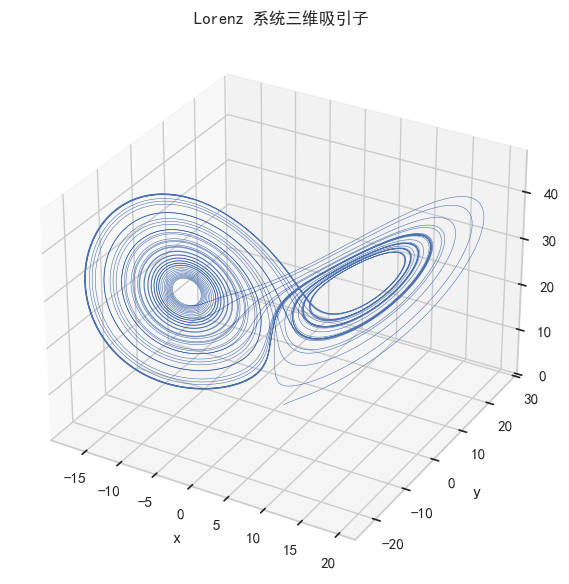

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(trajectory["x"], trajectory["y"], trajectory["z"], linewidth=0.4)
ax.set_title("Lorenz 系统三维吸引子")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lorenz_attractor.png", dpi=300, bbox_inches="tight")
plt.show()

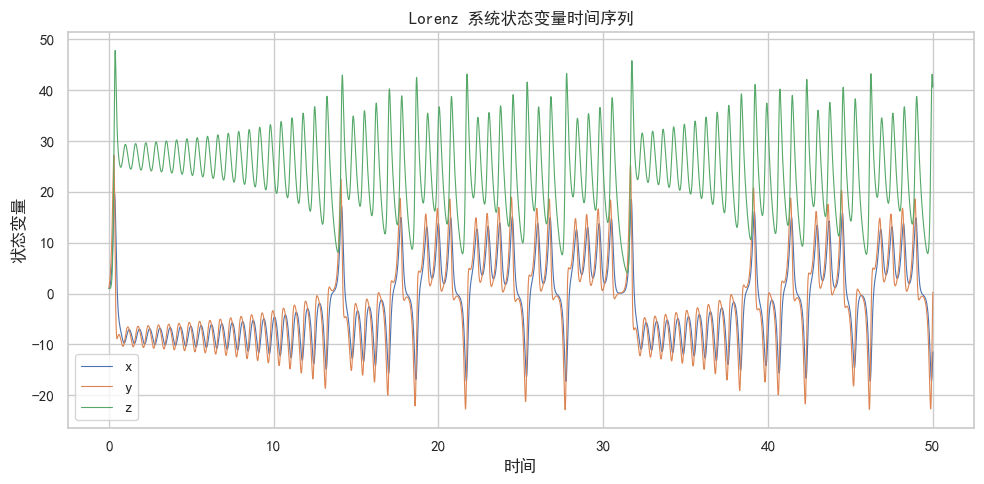

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(trajectory["time"], trajectory["x"], label="x", linewidth=0.8)
plt.plot(trajectory["time"], trajectory["y"], label="y", linewidth=0.8)
plt.plot(trajectory["time"], trajectory["z"], label="z", linewidth=0.8)
plt.xlabel("时间")
plt.ylabel("状态变量")
plt.title("Lorenz 系统状态变量时间序列")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lorenz_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

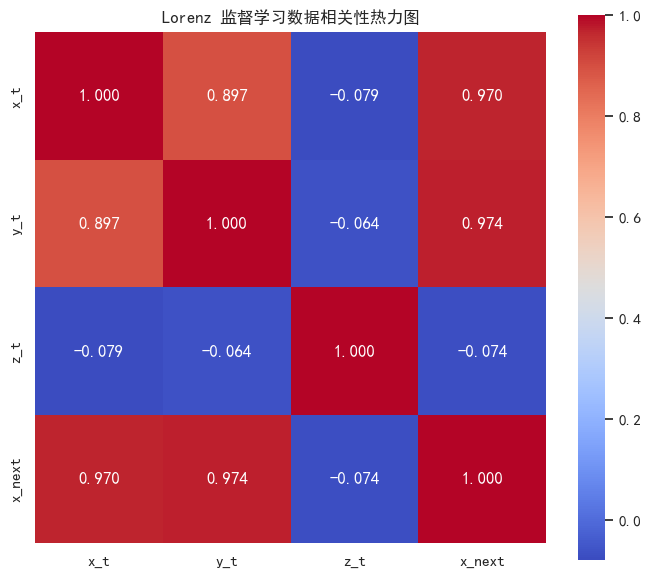

In [7]:
plt.figure(figsize=(7, 6))
corr = supervised.corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", square=True)
plt.title("Lorenz 监督学习数据相关性热力图")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. 训练集/测试集划分与 StandardScaler 标准化

为了尊重时间序列顺序，本文采用前 80% 样本作为训练集，后 20% 样本作为测试集。StandardScaler 只在训练集上 fit，再应用到训练集和测试集。


In [8]:
feature_cols = ["x_t", "y_t", "z_t"]
target_col = "x_next"

X = supervised[feature_cols].to_numpy()
y = supervised[target_col].to_numpy()

split_index = int(len(supervised) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standardization_check = pd.DataFrame({
    "feature": feature_cols,
    "train_scaled_mean": X_train_scaled.mean(axis=0),
    "train_scaled_std": X_train_scaled.std(axis=0),
})
standardization_check.to_csv(RESULTS_DIR / "standardization_check.csv", index=False)

print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")
standardization_check

训练集样本数: 7992
测试集样本数: 1998


,feature,train_scaled_mean,train_scaled_std
0,x_t,-2.845016e-17,1.0
1,y_t,0.000000e+00,1.0
2,z_t,-9.957556e-17,1.0


## 7. 模型训练与评价

In [9]:
def evaluate_regression(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

predictions = {}
metrics = {}

persistence_pred = X_test[:, 0]
predictions["Persistence"] = persistence_pred
metrics["Persistence"] = evaluate_regression(y_test, persistence_pred)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)
predictions["Linear Regression"] = linear_pred
metrics["Linear Regression"] = evaluate_regression(y_test, linear_pred)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
predictions["Random Forest"] = rf_pred
metrics["Random Forest"] = evaluate_regression(y_test, rf_pred)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=600,
    early_stopping=True,
    random_state=RANDOM_STATE,
)
mlp_model.fit(X_train_scaled, y_train)
mlp_pred = mlp_model.predict(X_test_scaled)
predictions["MLP"] = mlp_pred
metrics["MLP"] = evaluate_regression(y_test, mlp_pred)

metrics_df = pd.DataFrame(metrics).T
metrics_df.to_csv(RESULTS_DIR / "model_metrics.csv")
metrics_df

,RMSE,MAE,R2
Persistence,2.165343,1.765714,0.920785
Linear Regression,0.567887,0.455593,0.994552
Random Forest,0.088720,0.050448,0.999867
MLP,0.077883,0.057412,0.999898


## 8. 真实值 vs 预测值散点图

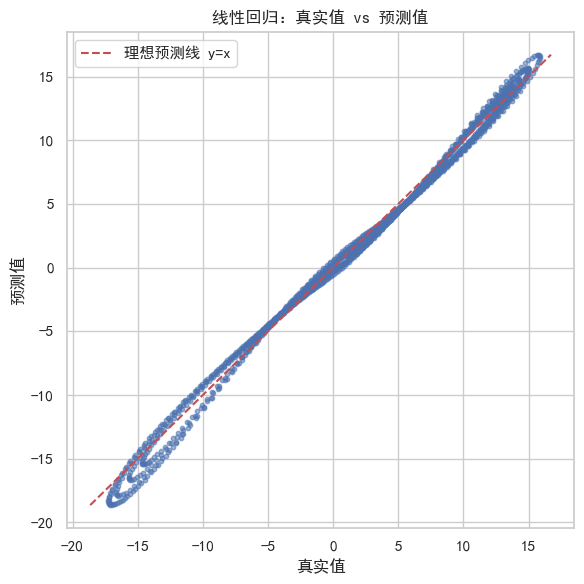

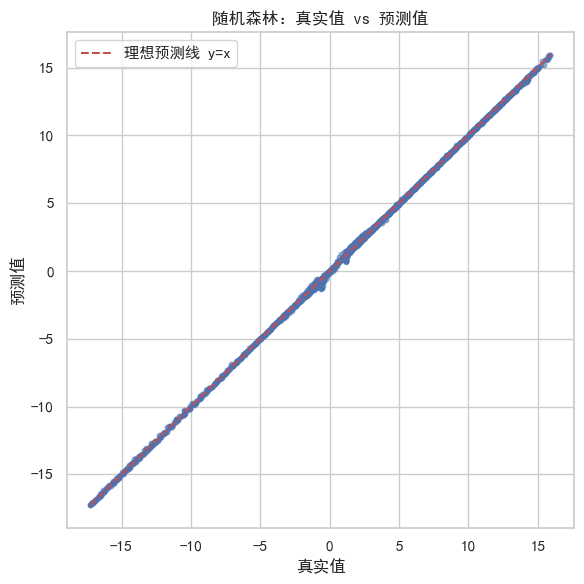

In [10]:
def plot_prediction_scatter(y_true, y_pred, title, filename):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.55)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="理想预测线 y=x")
    plt.xlabel("真实值")
    plt.ylabel("预测值")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_prediction_scatter(y_test, linear_pred, "线性回归：真实值 vs 预测值", "prediction_scatter_linear.png")
plot_prediction_scatter(y_test, rf_pred, "随机森林：真实值 vs 预测值", "prediction_scatter_rf.png")

## 9. 时间序列预测对比、残差与模型对比图

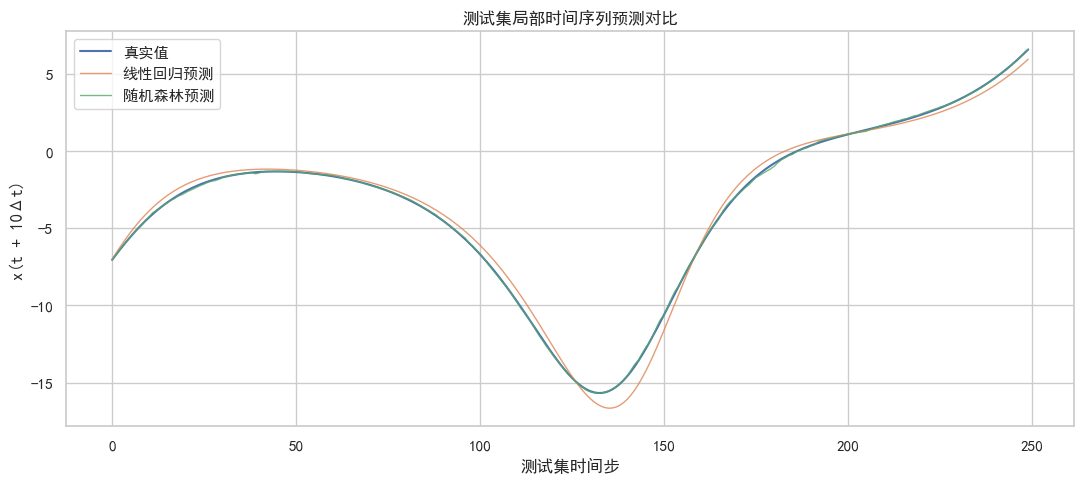

In [11]:
n_display = 250
plt.figure(figsize=(11, 5))
plt.plot(y_test[:n_display], label="真实值", linewidth=1.5)
plt.plot(linear_pred[:n_display], label="线性回归预测", linewidth=1.0, alpha=0.8)
plt.plot(rf_pred[:n_display], label="随机森林预测", linewidth=1.0, alpha=0.8)
plt.xlabel("测试集时间步")
plt.ylabel("x(t + 10Δt)")
plt.title("测试集局部时间序列预测对比")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "time_series_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

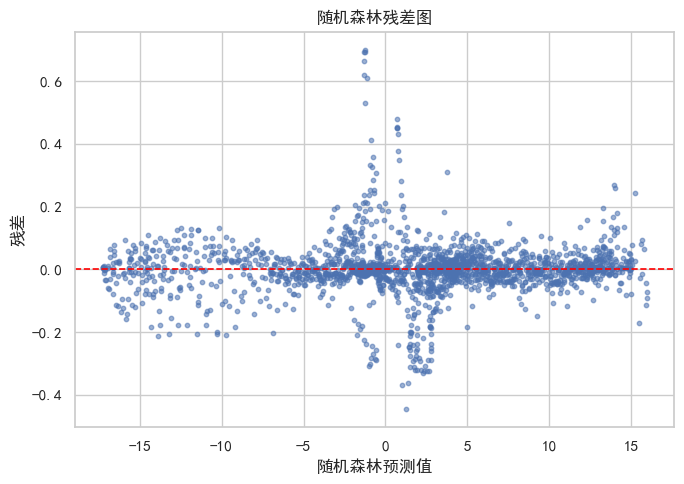

In [12]:
residuals = y_test - rf_pred
plt.figure(figsize=(7, 5))
plt.scatter(rf_pred, residuals, s=10, alpha=0.55)
plt.axhline(0, color="red", linestyle="--", linewidth=1.2)
plt.xlabel("随机森林预测值")
plt.ylabel("残差")
plt.title("随机森林残差图")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals.png", dpi=300, bbox_inches="tight")
plt.show()

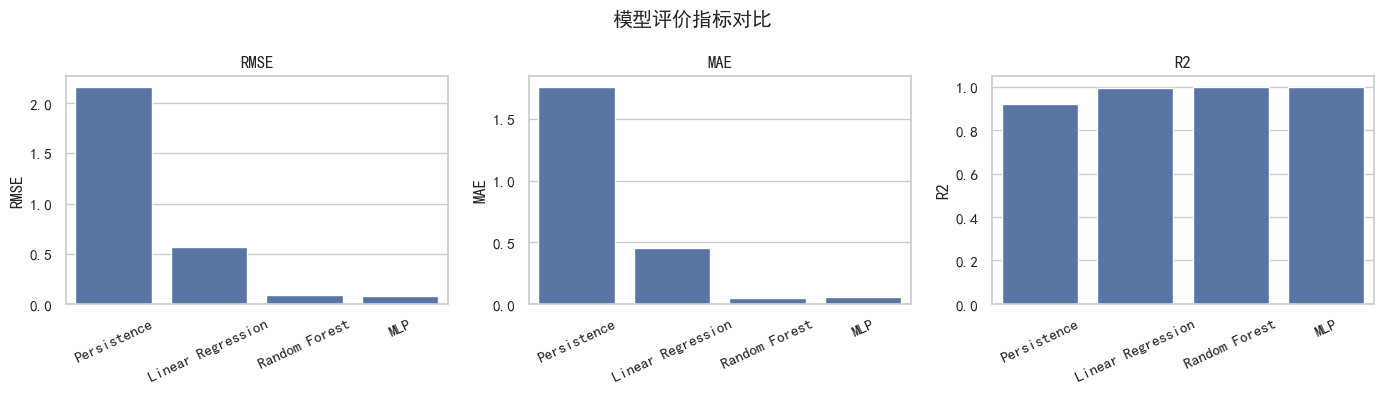

In [13]:
metrics_plot = metrics_df.reset_index().rename(columns={"index": "model"})
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    sns.barplot(data=metrics_plot, x="model", y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("模型评价指标对比")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

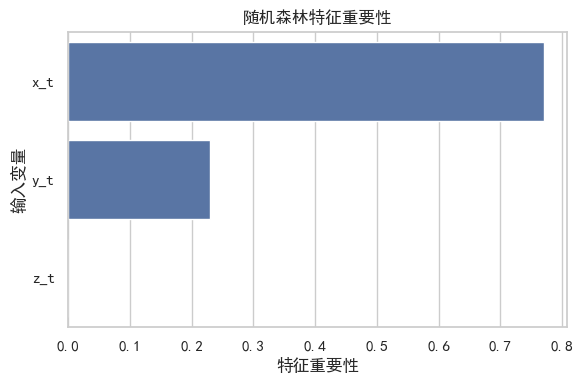

,feature,importance
0,x_t,0.770017
1,y_t,0.229809
2,z_t,0.000174


In [14]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)
importance_df.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.xlabel("特征重要性")
plt.ylabel("输入变量")
plt.title("随机森林特征重要性")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
importance_df

## 10. 导出报告回填所需摘要

In [15]:
summary = {
    "sigma": sigma,
    "rho": rho,
    "beta": beta,
    "initial_state": initial_state,
    "t_start": t_start,
    "t_end": t_end,
    "n_points": n_points,
    "prediction_horizon": prediction_horizon,
    "delta_t": float(t_eval[1] - t_eval[0]),
    "effective_prediction_time": float((t_eval[1] - t_eval[0]) * prediction_horizon),
    "dataset_rows": int(len(supervised)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "missing_values": {k: int(v) for k, v in missing_values.to_dict().items()},
    "metrics": metrics,
}

with open(RESULTS_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary

{'sigma': 10,
 'rho': 28,
 'beta': 2.6666666666666665,
 'initial_state': [1.0, 1.0, 1.0],
 't_start': 0,
 't_end': 50,
 'n_points': 10000,
 'prediction_horizon': 10,
 'delta_t': 0.005000500050005001,
 'effective_prediction_time': 0.05000500050005001,
 'dataset_rows': 9990,
 'train_rows': 7992,
 'test_rows': 1998,
 'missing_values': {'x_t': 0, 'y_t': 0, 'z_t': 0, 'x_next': 0},
 'metrics': {'Persistence': {'RMSE': 2.1653426784085683,
   'MAE': 1.7657140367272708,
   'R2': 0.9207854046804976},
  'Linear Regression': {'RMSE': 0.5678866495694991,
   'MAE': 0.4555931419186525,
   'R2': 0.9945515213403179},
  'Random Forest': {'RMSE': 0.0887202724399013,
   'MAE': 0.050448445368499344,
   'R2': 0.9998670165273196},
  'MLP': {'RMSE': 0.07788330708130353,
   'MAE': 0.05741184416633165,
   'R2': 0.9998975196252782}}}

## 11. 增强实验：三维状态预测、预测步长、递归 rollout 与初始条件泛化

前面的实验只预测固定 10 步后的单一 `x` 分量。为了更完整地分析 Lorenz 混沌系统中的机器学习预测能力，本节将任务扩展为完整状态转移预测：

\[
\mathbf{s}_t=(x_t,y_t,z_t) \rightarrow \mathbf{s}_{t+k}=(x_{t+k},y_{t+k},z_{t+k}).
\]

增强实验包括：

1. 不同 prediction horizon 下的三维状态预测；
2. one-step 状态转移模型的 recursive multi-step rollout；
3. 不同初始条件轨迹上的泛化测试。

In [16]:
from sklearn.multioutput import MultiOutputRegressor

STATE_COLS = ["x", "y", "z"]
FEATURE_COLS_STATE = ["x_t", "y_t", "z_t"]
TARGET_COLS_STATE = ["x_future", "y_future", "z_future"]
HORIZONS = [1, 5, 10, 20, 50, 100, 200, 500]
GENERALIZATION_INITIAL_CONDITIONS = [
    (1.01, 1.0, 1.0),
    (1.1, 1.0, 1.0),
    (-5.0, 5.0, 20.0),
    (10.0, 10.0, 10.0),
]


def simulate_lorenz(initial_state, t_start=t_start, t_end=t_end, n_points=n_points, sigma=sigma, rho=rho, beta=beta):
    t_eval_local = np.linspace(t_start, t_end, n_points)
    solution_local = solve_ivp(
        lambda t, state: lorenz_system(t, state, sigma=sigma, rho=rho, beta=beta),
        (t_start, t_end),
        initial_state,
        t_eval=t_eval_local,
        method="RK45",
        rtol=1e-9,
        atol=1e-12,
    )
    return pd.DataFrame({
        "time": solution_local.t,
        "x": solution_local.y[0],
        "y": solution_local.y[1],
        "z": solution_local.y[2],
    })


def build_state_dataset(trajectory_df, horizon):
    states = trajectory_df[STATE_COLS].to_numpy()
    return pd.DataFrame({
        "x_t": states[:-horizon, 0],
        "y_t": states[:-horizon, 1],
        "z_t": states[:-horizon, 2],
        "x_future": states[horizon:, 0],
        "y_future": states[horizon:, 1],
        "z_future": states[horizon:, 2],
    })


def state_rmse(y_true, y_pred):
    state_error = np.linalg.norm(y_true - y_pred, axis=1)
    return float(np.sqrt(np.mean(state_error ** 2)))


def evaluate_state_prediction(y_true, y_pred):
    errors = y_true - y_pred
    state_abs_error = np.linalg.norm(errors, axis=1)
    metrics = {
        "RMSE_state": state_rmse(y_true, y_pred),
        "MAE_state": float(np.mean(state_abs_error)),
        "R2_mean": float(np.mean([r2_score(y_true[:, i], y_pred[:, i]) for i in range(3)])),
    }
    for i, axis_name in enumerate(STATE_COLS):
        metrics[f"RMSE_{axis_name}"] = float(np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])))
        metrics[f"MAE_{axis_name}"] = float(mean_absolute_error(y_true[:, i], y_pred[:, i]))
        metrics[f"R2_{axis_name}"] = float(r2_score(y_true[:, i], y_pred[:, i]))
    return metrics


def make_state_models():
    return {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            max_depth=18,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "MLP": MLPRegressor(
            hidden_layer_sizes=(64, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=600,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    }


def fit_state_models(X_train_scaled, y_train):
    fitted_models = {}
    for model_name, model in make_state_models().items():
        try:
            model.fit(X_train_scaled, y_train)
            fitted_models[model_name] = model
        except ValueError:
            wrapped_model = MultiOutputRegressor(model)
            wrapped_model.fit(X_train_scaled, y_train)
            fitted_models[model_name] = wrapped_model
    return fitted_models


def persistence_state_predict(X_values):
    return X_values.copy()


def train_test_state_split(dataset, train_fraction=0.8):
    split_idx = int(len(dataset) * train_fraction)
    X_values = dataset[FEATURE_COLS_STATE].to_numpy()
    y_values = dataset[TARGET_COLS_STATE].to_numpy()
    X_train, X_test = X_values[:split_idx], X_values[split_idx:]
    y_train, y_test = y_values[:split_idx], y_values[split_idx:]
    scaler_local = StandardScaler()
    X_train_scaled = scaler_local.fit_transform(X_train)
    X_test_scaled = scaler_local.transform(X_test)
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler_local, split_idx


def evaluate_state_models_for_dataset(dataset, horizon, setting="same_trajectory"):
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler_local, split_idx = train_test_state_split(dataset)
    rows = []

    persistence_pred = persistence_state_predict(X_test)
    persistence_metrics = evaluate_state_prediction(y_test, persistence_pred)
    rows.append({
        "setting": setting,
        "horizon": horizon,
        "effective_time": float((t_eval[1] - t_eval[0]) * horizon),
        "model": "Persistence",
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        **persistence_metrics,
    })

    fitted_models = fit_state_models(X_train_scaled, y_train)
    for model_name, fitted_model in fitted_models.items():
        pred = fitted_model.predict(X_test_scaled)
        model_metrics = evaluate_state_prediction(y_test, pred)
        rows.append({
            "setting": setting,
            "horizon": horizon,
            "effective_time": float((t_eval[1] - t_eval[0]) * horizon),
            "model": model_name,
            "train_rows": len(X_train),
            "test_rows": len(X_test),
            **model_metrics,
        })

    return rows, fitted_models, scaler_local, split_idx


print("增强实验公共函数已准备完成。")

增强实验公共函数已准备完成。


### 11.1 Prediction horizon 对三维状态预测误差的影响

本实验固定训练/测试划分方式，依次改变 prediction horizon。每个 horizon 都重新构造监督学习数据，并评价完整状态向量预测误差。

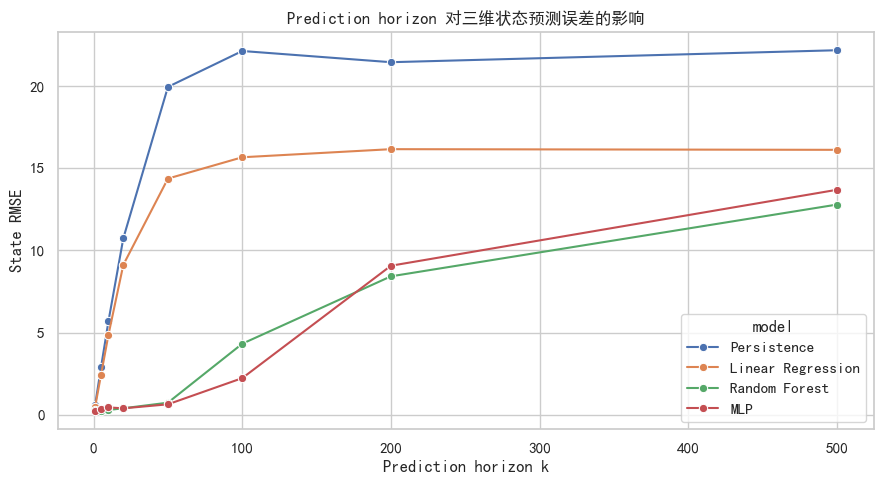

,horizon,effective_time,model,RMSE_state,MAE_state,R2_mean
0,1,0.005001,Persistence,0.583223,0.499562,0.998517
1,1,0.005001,Linear Regression,0.480285,0.406795,0.999046
2,1,0.005001,Random Forest,0.287167,0.201605,0.999636
3,1,0.005001,MLP,0.226062,0.199539,0.999760
4,5,0.025003,Persistence,2.898293,2.486825,0.963378
5,5,0.025003,Linear Regression,2.439457,2.099571,0.975342
6,5,0.025003,Random Forest,0.265668,0.187900,0.999691
7,5,0.025003,MLP,0.380910,0.330325,0.999349
8,10,0.050005,Persistence,5.700977,4.916380,0.858273
9,10,0.050005,Linear Regression,4.877242,4.275752,0.901026


In [17]:
horizon_rows = []
horizon_models = {}
horizon_scalers = {}

for horizon_k in HORIZONS:
    state_dataset = build_state_dataset(trajectory, horizon_k)
    rows, fitted_models, scaler_for_horizon, split_idx = evaluate_state_models_for_dataset(
        state_dataset,
        horizon=horizon_k,
        setting="same_trajectory",
    )
    horizon_rows.extend(rows)
    horizon_models[horizon_k] = fitted_models
    horizon_scalers[horizon_k] = scaler_for_horizon

horizon_results = pd.DataFrame(horizon_rows)
horizon_results.to_csv(RESULTS_DIR / "horizon_results.csv", index=False)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=horizon_results,
    x="horizon",
    y="RMSE_state",
    hue="model",
    marker="o",
)
plt.xlabel("Prediction horizon k")
plt.ylabel("State RMSE")
plt.title("Prediction horizon 对三维状态预测误差的影响")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "horizon_vs_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

horizon_results[["horizon", "effective_time", "model", "RMSE_state", "MAE_state", "R2_mean"]]

### 11.2 Recursive multi-step rollout

本实验训练 one-step 状态转移模型，然后从测试段第一个真实状态开始递归预测。除初始状态外，后续每一步都使用模型自己的预测作为下一步输入。

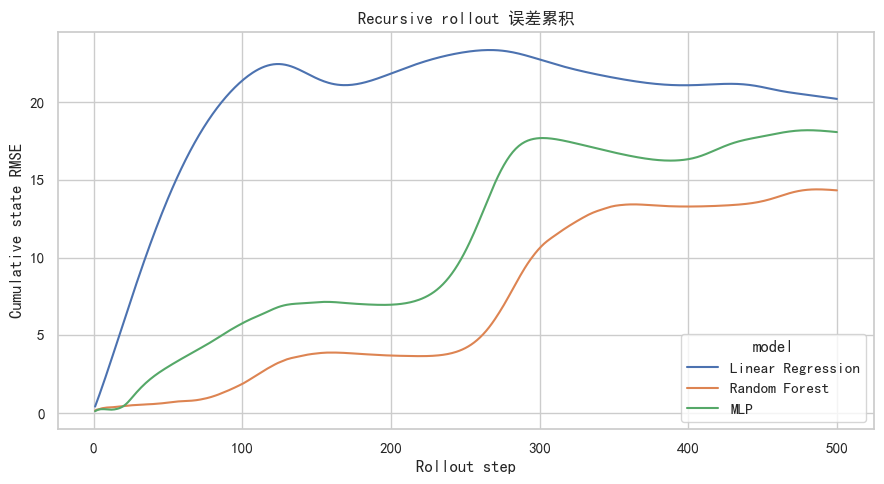

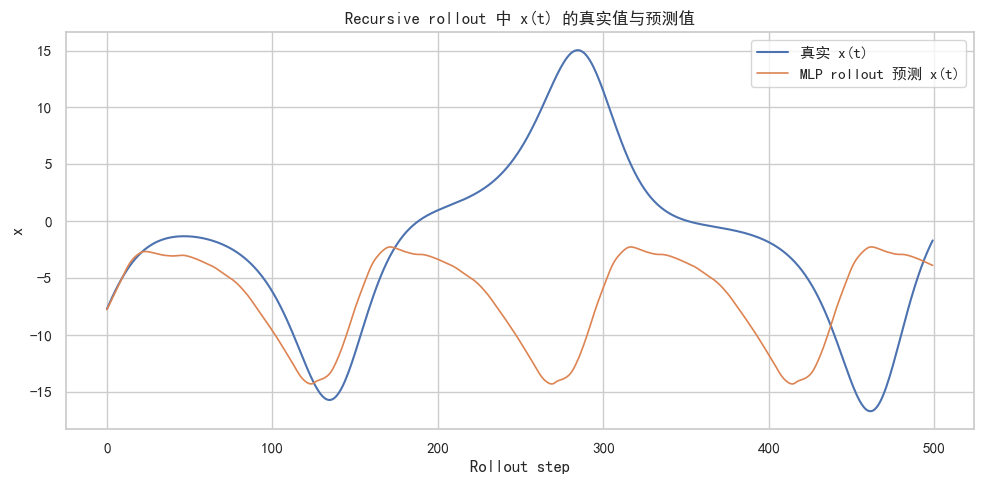

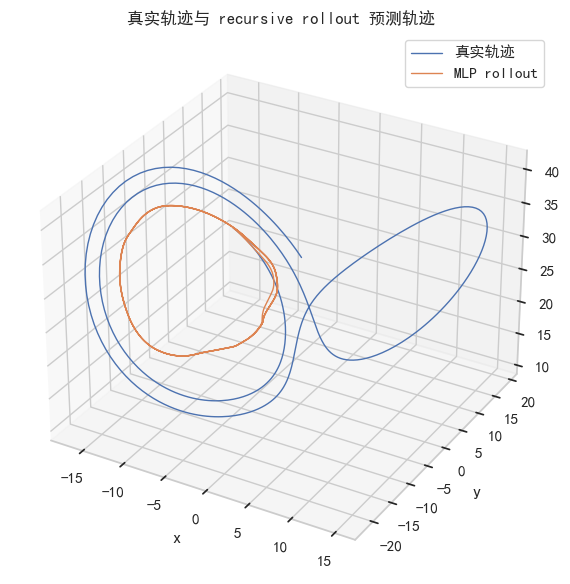

,state_error,cumulative_RMSE_state
499,10.766498,20.203974
999,9.699301,14.325495
1499,12.594194,18.071099


In [18]:
def rollout_model(fitted_model, scaler_local, initial_state, steps):
    current_state = np.asarray(initial_state, dtype=float).reshape(1, -1)
    predictions = []
    for _ in range(steps):
        current_scaled = scaler_local.transform(current_state)
        next_state = fitted_model.predict(current_scaled)
        next_state = np.asarray(next_state).reshape(1, -1)
        predictions.append(next_state.ravel())
        current_state = next_state
    return np.asarray(predictions)


rollout_steps = 500
one_step_dataset = build_state_dataset(trajectory, horizon=1)
X_train_one, X_test_one, X_train_one_scaled, X_test_one_scaled, y_train_one, y_test_one, one_step_scaler, one_step_split_idx = train_test_state_split(one_step_dataset)
one_step_models = fit_state_models(X_train_one_scaled, y_train_one)

rollout_rows = []
rollout_predictions = {}
true_rollout = trajectory[STATE_COLS].iloc[one_step_split_idx + 1:one_step_split_idx + 1 + rollout_steps].to_numpy()
rollout_initial_state = trajectory[STATE_COLS].iloc[one_step_split_idx].to_numpy()

for model_name, fitted_model in one_step_models.items():
    predicted_rollout = rollout_model(fitted_model, one_step_scaler, rollout_initial_state, rollout_steps)
    rollout_predictions[model_name] = predicted_rollout
    step_errors = np.linalg.norm(true_rollout - predicted_rollout, axis=1)
    for step_idx, error_value in enumerate(step_errors, start=1):
        component_error = true_rollout[step_idx - 1] - predicted_rollout[step_idx - 1]
        rollout_rows.append({
            "model": model_name,
            "rollout_step": step_idx,
            "state_error": float(error_value),
            "squared_state_error": float(error_value ** 2),
            "abs_error_x": float(abs(component_error[0])),
            "abs_error_y": float(abs(component_error[1])),
            "abs_error_z": float(abs(component_error[2])),
            "true_x": float(true_rollout[step_idx - 1, 0]),
            "true_y": float(true_rollout[step_idx - 1, 1]),
            "true_z": float(true_rollout[step_idx - 1, 2]),
            "pred_x": float(predicted_rollout[step_idx - 1, 0]),
            "pred_y": float(predicted_rollout[step_idx - 1, 1]),
            "pred_z": float(predicted_rollout[step_idx - 1, 2]),
        })

rollout_results = pd.DataFrame(rollout_rows)
rollout_results["cumulative_RMSE_state"] = rollout_results.groupby("model")["squared_state_error"].transform(
    lambda values: np.sqrt(np.cumsum(values) / np.arange(1, len(values) + 1))
)
rollout_results.to_csv(RESULTS_DIR / "rollout_results.csv", index=False)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=rollout_results,
    x="rollout_step",
    y="cumulative_RMSE_state",
    hue="model",
)
plt.xlabel("Rollout step")
plt.ylabel("Cumulative state RMSE")
plt.title("Recursive rollout 误差累积")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rollout_error.png", dpi=300, bbox_inches="tight")
plt.show()

main_rollout_model = "MLP" if "MLP" in rollout_predictions else list(rollout_predictions.keys())[0]
main_predicted_rollout = rollout_predictions[main_rollout_model]

plt.figure(figsize=(10, 5))
plt.plot(true_rollout[:, 0], label="真实 x(t)", linewidth=1.5)
plt.plot(main_predicted_rollout[:, 0], label=f"{main_rollout_model} rollout 预测 x(t)", linewidth=1.2)
plt.xlabel("Rollout step")
plt.ylabel("x")
plt.title("Recursive rollout 中 x(t) 的真实值与预测值")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rollout_x_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(true_rollout[:, 0], true_rollout[:, 1], true_rollout[:, 2], label="真实轨迹", linewidth=1.0)
ax.plot(main_predicted_rollout[:, 0], main_predicted_rollout[:, 1], main_predicted_rollout[:, 2], label=f"{main_rollout_model} rollout", linewidth=1.0)
ax.set_title("真实轨迹与 recursive rollout 预测轨迹")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rollout_attractor.png", dpi=300, bbox_inches="tight")
plt.show()

rollout_results.groupby("model")[["state_error", "cumulative_RMSE_state"]].tail(1)

### 11.3 不同初始条件泛化测试

本实验不对新初始条件重新训练模型，而是使用 `(1,1,1)` 轨迹上训练好的 horizon=10 状态预测模型，直接测试其他初始条件生成的轨迹。

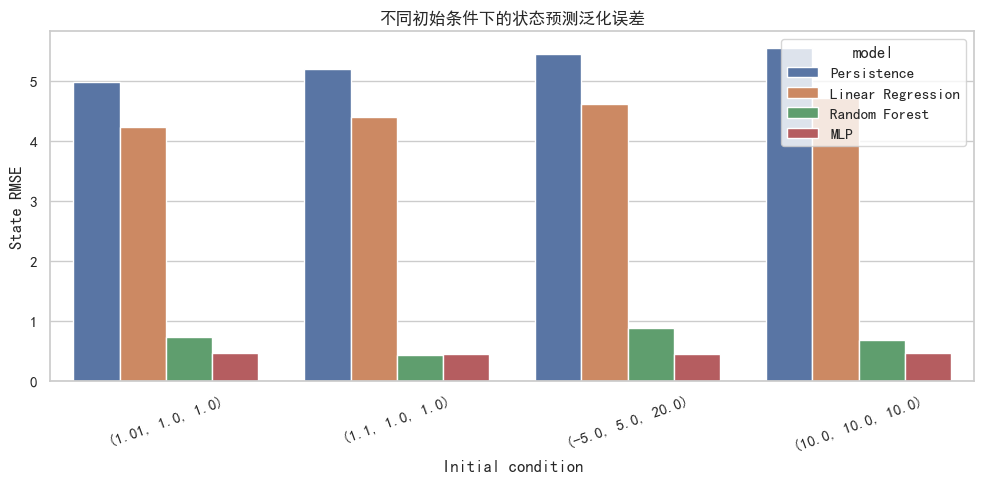

,initial_condition,model,RMSE_state,MAE_state,R2_mean
0,"(1.01, 1.0, 1.0)",Persistence,4.988507,4.136336,0.876470
1,"(1.01, 1.0, 1.0)",Linear Regression,4.234020,3.551086,0.910943
2,"(1.01, 1.0, 1.0)",Random Forest,0.726323,0.341039,0.997442
3,"(1.01, 1.0, 1.0)",MLP,0.466919,0.324929,0.998985
4,"(1.1, 1.0, 1.0)",Persistence,5.204024,4.355259,0.870726
5,"(1.1, 1.0, 1.0)",Linear Regression,4.403589,3.726032,0.907797
6,"(1.1, 1.0, 1.0)",Random Forest,0.430145,0.287460,0.999124
7,"(1.1, 1.0, 1.0)",MLP,0.443388,0.323368,0.999111
8,"(-5.0, 5.0, 20.0)",Persistence,5.452037,4.706129,0.867150
9,"(-5.0, 5.0, 20.0)",Linear Regression,4.623488,4.046568,0.906525


In [19]:
generalization_horizon = 10
base_state_dataset = build_state_dataset(trajectory, generalization_horizon)
X_train_base, X_test_base, X_train_base_scaled, X_test_base_scaled, y_train_base, y_test_base, base_scaler, base_split_idx = train_test_state_split(base_state_dataset)
base_models = fit_state_models(X_train_base_scaled, y_train_base)

generalization_rows = []

for initial_condition in GENERALIZATION_INITIAL_CONDITIONS:
    test_trajectory = simulate_lorenz(initial_condition)
    test_dataset = build_state_dataset(test_trajectory, generalization_horizon)
    X_generalization = test_dataset[FEATURE_COLS_STATE].to_numpy()
    y_generalization = test_dataset[TARGET_COLS_STATE].to_numpy()
    X_generalization_scaled = base_scaler.transform(X_generalization)
    ic_label = f"({initial_condition[0]}, {initial_condition[1]}, {initial_condition[2]})"

    persistence_pred = persistence_state_predict(X_generalization)
    persistence_metrics = evaluate_state_prediction(y_generalization, persistence_pred)
    generalization_rows.append({
        "initial_condition": ic_label,
        "horizon": generalization_horizon,
        "model": "Persistence",
        "test_rows": len(X_generalization),
        **persistence_metrics,
    })

    for model_name, fitted_model in base_models.items():
        pred = fitted_model.predict(X_generalization_scaled)
        model_metrics = evaluate_state_prediction(y_generalization, pred)
        generalization_rows.append({
            "initial_condition": ic_label,
            "horizon": generalization_horizon,
            "model": model_name,
            "test_rows": len(X_generalization),
            **model_metrics,
        })

initial_condition_generalization = pd.DataFrame(generalization_rows)
initial_condition_generalization.to_csv(RESULTS_DIR / "initial_condition_generalization.csv", index=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=initial_condition_generalization,
    x="initial_condition",
    y="RMSE_state",
    hue="model",
)
plt.xlabel("Initial condition")
plt.ylabel("State RMSE")
plt.title("不同初始条件下的状态预测泛化误差")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "initial_condition_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

initial_condition_generalization[["initial_condition", "model", "RMSE_state", "MAE_state", "R2_mean"]]

## 12. 模型增强：输出标准化、Residual MLP、MLP 消融与 Echo State Network

前面的实验已经说明：短期三维状态预测相对容易，但 horizon 增大和 recursive rollout 会显著增加误差。本节进一步比较不同模型结构是否更适合学习 Lorenz 系统的连续状态转移映射。

重点比较：

1. **Direct MLP**：直接预测未来状态 $\mathbf{s}_{t+k}$；
2. **Residual MLP**：预测状态变化量 $\Delta \mathbf{s}=\mathbf{s}_{t+k}-\mathbf{s}_t$，再还原为 $\hat{\mathbf{s}}_{t+k}=\mathbf{s}_t+\widehat{\Delta \mathbf{s}}$；
3. **输出标准化**：对目标 $Y=(x,y,z)$ 或 $\Delta Y$ 使用 StandardScaler；
4. **MLP 小消融**：比较不同隐藏层结构和激活函数；
5. **Echo State Network**：加入一个轻量 reservoir computing 模型作为动力系统时间序列模型。

In [20]:
ENHANCEMENT_HORIZONS = [10, 100, 500]

MLP_ABLATION_CONFIGS = [
    {"name": "MLP-direct-scaled-relu-64x64", "mode": "direct", "hidden_layer_sizes": (64, 64), "activation": "relu"},
    {"name": "MLP-residual-relu-32x32", "mode": "residual", "hidden_layer_sizes": (32, 32), "activation": "relu"},
    {"name": "MLP-residual-relu-64x64", "mode": "residual", "hidden_layer_sizes": (64, 64), "activation": "relu"},
    {"name": "MLP-residual-relu-128x128", "mode": "residual", "hidden_layer_sizes": (128, 128), "activation": "relu"},
    {"name": "MLP-residual-relu-64x64x64", "mode": "residual", "hidden_layer_sizes": (64, 64, 64), "activation": "relu"},
    {"name": "MLP-residual-tanh-64x64", "mode": "residual", "hidden_layer_sizes": (64, 64), "activation": "tanh"},
]


def make_scaled_mlp(hidden_layer_sizes=(64, 64), activation="relu", random_state=RANDOM_STATE):
    return MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        random_state=random_state,
    )


def fit_scaled_mlp_state_model(X_train, X_train_scaled, y_train, config):
    y_scaler = StandardScaler()
    if config["mode"] == "residual":
        target_train = y_train - X_train
    else:
        target_train = y_train
    target_train_scaled = y_scaler.fit_transform(target_train)
    model = make_scaled_mlp(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        activation=config["activation"],
    )
    model.fit(X_train_scaled, target_train_scaled)
    return {"model": model, "y_scaler": y_scaler, "mode": config["mode"], "name": config["name"]}


def predict_scaled_mlp_state(fitted_bundle, X_values, X_scaled):
    pred_target_scaled = fitted_bundle["model"].predict(X_scaled)
    pred_target = fitted_bundle["y_scaler"].inverse_transform(pred_target_scaled)
    if fitted_bundle["mode"] == "residual":
        return X_values + pred_target
    return pred_target


class EchoStateRegressor:
    def __init__(self, n_reservoir=200, spectral_radius=0.9, input_scale=0.5, leak_rate=0.3, ridge=1e-5, random_state=RANDOM_STATE):
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.input_scale = input_scale
        self.leak_rate = leak_rate
        self.ridge = ridge
        self.random_state = random_state

    def _initialize(self, input_dim):
        rng = np.random.default_rng(self.random_state)
        self.W_in_ = rng.uniform(-self.input_scale, self.input_scale, size=(self.n_reservoir, input_dim + 1))
        W = rng.uniform(-1.0, 1.0, size=(self.n_reservoir, self.n_reservoir))
        eig_radius = np.max(np.abs(np.linalg.eigvals(W)))
        self.W_ = W * (self.spectral_radius / eig_radius)

    def _step(self, input_vector, reservoir_state):
        augmented_input = np.concatenate(([1.0], input_vector))
        pre_activation = self.W_in_ @ augmented_input + self.W_ @ reservoir_state
        updated = np.tanh(pre_activation)
        return (1.0 - self.leak_rate) * reservoir_state + self.leak_rate * updated

    def _collect_states(self, X):
        reservoir_state = np.zeros(self.n_reservoir)
        states = []
        for input_vector in X:
            reservoir_state = self._step(input_vector, reservoir_state)
            states.append(reservoir_state.copy())
        return np.asarray(states)

    def fit(self, X, y):
        self._initialize(X.shape[1])
        states = self._collect_states(X)
        design = np.hstack([np.ones((len(X), 1)), X, states])
        regularizer = self.ridge * np.eye(design.shape[1])
        self.W_out_ = np.linalg.solve(design.T @ design + regularizer, design.T @ y)
        return self

    def predict(self, X):
        states = self._collect_states(X)
        design = np.hstack([np.ones((len(X), 1)), X, states])
        return design @ self.W_out_

    def step_predict(self, input_vector, reservoir_state):
        next_reservoir_state = self._step(input_vector, reservoir_state)
        design = np.concatenate(([1.0], input_vector, next_reservoir_state))
        return design @ self.W_out_, next_reservoir_state


def fit_esn_residual_model(X_train, X_train_scaled, y_train):
    delta_scaler = StandardScaler()
    delta_train_scaled = delta_scaler.fit_transform(y_train - X_train)
    esn_model = EchoStateRegressor()
    esn_model.fit(X_train_scaled, delta_train_scaled)
    return {"model": esn_model, "delta_scaler": delta_scaler, "mode": "residual", "name": "ESN-residual"}


def predict_esn_residual(bundle, X_values, X_scaled):
    delta_scaled = bundle["model"].predict(X_scaled)
    delta = bundle["delta_scaler"].inverse_transform(delta_scaled)
    return X_values + delta


print("模型增强函数已准备完成。")

模型增强函数已准备完成。


### 12.1 Horizon 上的 Residual MLP、输出标准化与 ESN 对比

这里选取 `horizon=10, 100, 500` 三个代表性预测跨度：短期、中期和较长 horizon。比较结果用于回答：输出标准化、residual learning 和 ESN 是否能改善三维状态预测。

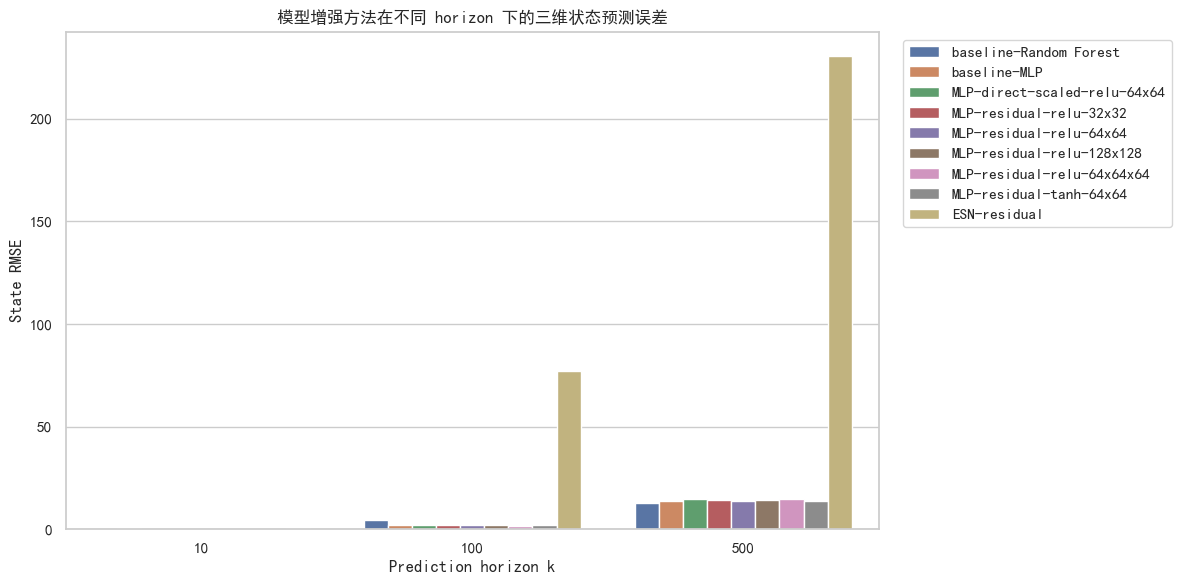

,horizon,model,RMSE_state,R2_mean
6,10,MLP-residual-relu-64x64x64,0.077202,0.999974
5,10,MLP-residual-relu-128x128,0.082848,0.999971
4,10,MLP-residual-relu-64x64,0.106727,0.999951
7,10,MLP-residual-tanh-64x64,0.115766,0.999943
3,10,MLP-residual-relu-32x32,0.178714,0.999864
2,10,MLP-direct-scaled-relu-64x64,0.222656,0.999779
0,10,baseline-Random Forest,0.298699,0.999599
8,10,ESN-residual,0.456644,0.999123
1,10,baseline-MLP,0.457193,0.999083
15,100,MLP-residual-relu-64x64x64,1.413322,0.991283


In [21]:
model_enhancement_rows = []

for horizon_k in ENHANCEMENT_HORIZONS:
    state_dataset = build_state_dataset(trajectory, horizon_k)
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler_local, split_idx = train_test_state_split(state_dataset)

    baseline_subset = horizon_results[
        (horizon_results["horizon"] == horizon_k)
        & (horizon_results["model"].isin(["Random Forest", "MLP"]))
    ].copy()
    for _, row in baseline_subset.iterrows():
        model_enhancement_rows.append({
            "horizon": horizon_k,
            "model": f"baseline-{row['model']}",
            "family": "baseline",
            "RMSE_state": row["RMSE_state"],
            "MAE_state": row["MAE_state"],
            "R2_mean": row["R2_mean"],
            "RMSE_x": row["RMSE_x"],
            "RMSE_y": row["RMSE_y"],
            "RMSE_z": row["RMSE_z"],
        })

    for config in MLP_ABLATION_CONFIGS:
        fitted_bundle = fit_scaled_mlp_state_model(X_train, X_train_scaled, y_train, config)
        pred = predict_scaled_mlp_state(fitted_bundle, X_test, X_test_scaled)
        metrics = evaluate_state_prediction(y_test, pred)
        model_enhancement_rows.append({
            "horizon": horizon_k,
            "model": config["name"],
            "family": "MLP",
            **metrics,
        })

    esn_bundle = fit_esn_residual_model(X_train, X_train_scaled, y_train)
    esn_pred = predict_esn_residual(esn_bundle, X_test, X_test_scaled)
    esn_metrics = evaluate_state_prediction(y_test, esn_pred)
    model_enhancement_rows.append({
        "horizon": horizon_k,
        "model": "ESN-residual",
        "family": "ESN",
        **esn_metrics,
    })

model_enhancement_results = pd.DataFrame(model_enhancement_rows)
model_enhancement_results.to_csv(RESULTS_DIR / "model_enhancement_results.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=model_enhancement_results,
    x="horizon",
    y="RMSE_state",
    hue="model",
)
plt.xlabel("Prediction horizon k")
plt.ylabel("State RMSE")
plt.title("模型增强方法在不同 horizon 下的三维状态预测误差")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_enhancement_horizon_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

model_enhancement_results[["horizon", "model", "RMSE_state", "R2_mean"]].sort_values(["horizon", "RMSE_state"])

### 12.2 增强模型的 recursive rollout 对比

本实验把 Residual MLP 和 ESN 放到更严格的递归预测场景中，观察它们在 500 步 rollout 中的误差累积。

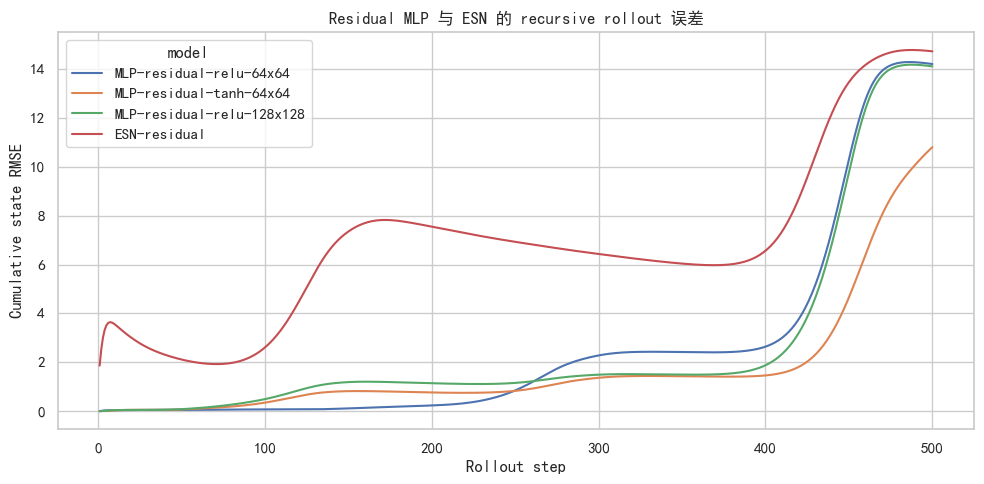

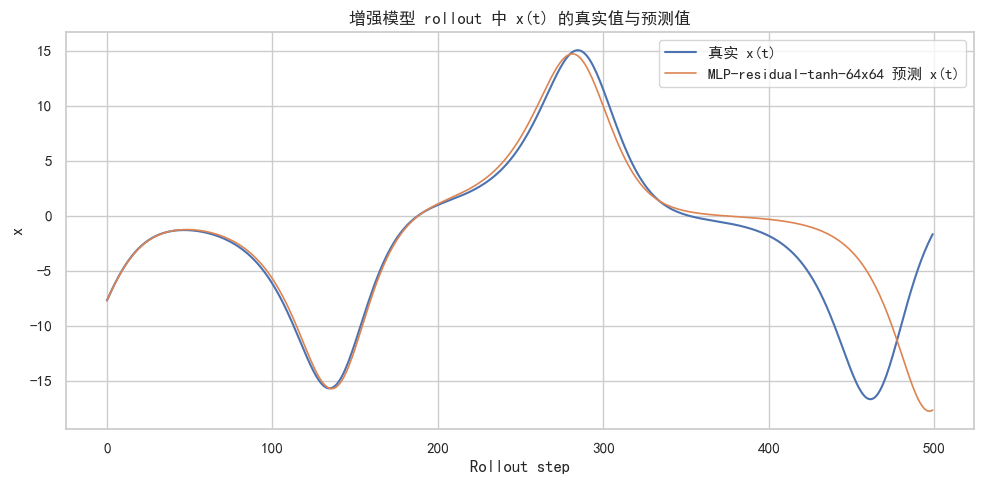

,state_error,cumulative_RMSE_state
999,28.358336,10.797463
1499,9.007487,14.099934
499,8.627508,14.194616
1999,10.652914,14.714380


In [22]:
def rollout_scaled_mlp_bundle(fitted_bundle, x_scaler, initial_state, steps):
    current_state = np.asarray(initial_state, dtype=float).reshape(1, -1)
    predictions = []
    for _ in range(steps):
        current_scaled = x_scaler.transform(current_state)
        next_state = predict_scaled_mlp_state(fitted_bundle, current_state, current_scaled)
        predictions.append(next_state.ravel())
        current_state = next_state.reshape(1, -1)
    return np.asarray(predictions)


def rollout_esn_bundle(esn_bundle, x_scaler, initial_state, steps):
    current_state = np.asarray(initial_state, dtype=float).reshape(1, -1)
    reservoir_state = np.zeros(esn_bundle["model"].n_reservoir)
    predictions = []
    for _ in range(steps):
        current_scaled = x_scaler.transform(current_state).ravel()
        delta_scaled, reservoir_state = esn_bundle["model"].step_predict(current_scaled, reservoir_state)
        delta = esn_bundle["delta_scaler"].inverse_transform(delta_scaled.reshape(1, -1))
        next_state = current_state + delta
        predictions.append(next_state.ravel())
        current_state = next_state
    return np.asarray(predictions)


enhanced_rollout_steps = 500
one_step_dataset = build_state_dataset(trajectory, horizon=1)
X_train_one, X_test_one, X_train_one_scaled, X_test_one_scaled, y_train_one, y_test_one, enhanced_one_scaler, enhanced_one_split_idx = train_test_state_split(one_step_dataset)
enhanced_true_rollout = trajectory[STATE_COLS].iloc[enhanced_one_split_idx + 1:enhanced_one_split_idx + 1 + enhanced_rollout_steps].to_numpy()
enhanced_initial_state = trajectory[STATE_COLS].iloc[enhanced_one_split_idx].to_numpy()

rollout_model_configs = [
    {"name": "MLP-residual-relu-64x64", "mode": "residual", "hidden_layer_sizes": (64, 64), "activation": "relu"},
    {"name": "MLP-residual-tanh-64x64", "mode": "residual", "hidden_layer_sizes": (64, 64), "activation": "tanh"},
    {"name": "MLP-residual-relu-128x128", "mode": "residual", "hidden_layer_sizes": (128, 128), "activation": "relu"},
]

enhanced_rollout_rows = []
enhanced_rollout_predictions = {}

for config in rollout_model_configs:
    fitted_bundle = fit_scaled_mlp_state_model(X_train_one, X_train_one_scaled, y_train_one, config)
    predicted_rollout = rollout_scaled_mlp_bundle(fitted_bundle, enhanced_one_scaler, enhanced_initial_state, enhanced_rollout_steps)
    enhanced_rollout_predictions[config["name"]] = predicted_rollout
    step_errors = np.linalg.norm(enhanced_true_rollout - predicted_rollout, axis=1)
    for step_idx, error_value in enumerate(step_errors, start=1):
        enhanced_rollout_rows.append({
            "model": config["name"],
            "rollout_step": step_idx,
            "state_error": float(error_value),
            "squared_state_error": float(error_value ** 2),
            "true_x": float(enhanced_true_rollout[step_idx - 1, 0]),
            "pred_x": float(predicted_rollout[step_idx - 1, 0]),
        })

esn_one_bundle = fit_esn_residual_model(X_train_one, X_train_one_scaled, y_train_one)
esn_rollout = rollout_esn_bundle(esn_one_bundle, enhanced_one_scaler, enhanced_initial_state, enhanced_rollout_steps)
enhanced_rollout_predictions["ESN-residual"] = esn_rollout
esn_step_errors = np.linalg.norm(enhanced_true_rollout - esn_rollout, axis=1)
for step_idx, error_value in enumerate(esn_step_errors, start=1):
    enhanced_rollout_rows.append({
        "model": "ESN-residual",
        "rollout_step": step_idx,
        "state_error": float(error_value),
        "squared_state_error": float(error_value ** 2),
        "true_x": float(enhanced_true_rollout[step_idx - 1, 0]),
        "pred_x": float(esn_rollout[step_idx - 1, 0]),
    })

enhanced_rollout_results = pd.DataFrame(enhanced_rollout_rows)
enhanced_rollout_results["cumulative_RMSE_state"] = enhanced_rollout_results.groupby("model")["squared_state_error"].transform(
    lambda values: np.sqrt(np.cumsum(values) / np.arange(1, len(values) + 1))
)
enhanced_rollout_results.to_csv(RESULTS_DIR / "enhanced_rollout_results.csv", index=False)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=enhanced_rollout_results,
    x="rollout_step",
    y="cumulative_RMSE_state",
    hue="model",
)
plt.xlabel("Rollout step")
plt.ylabel("Cumulative state RMSE")
plt.title("Residual MLP 与 ESN 的 recursive rollout 误差")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "enhanced_rollout_error.png", dpi=300, bbox_inches="tight")
plt.show()

best_enhanced_rollout_name = enhanced_rollout_results.groupby("model")["cumulative_RMSE_state"].last().idxmin()
best_enhanced_rollout = enhanced_rollout_predictions[best_enhanced_rollout_name]

plt.figure(figsize=(10, 5))
plt.plot(enhanced_true_rollout[:, 0], label="真实 x(t)", linewidth=1.5)
plt.plot(best_enhanced_rollout[:, 0], label=f"{best_enhanced_rollout_name} 预测 x(t)", linewidth=1.2)
plt.xlabel("Rollout step")
plt.ylabel("x")
plt.title("增强模型 rollout 中 x(t) 的真实值与预测值")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "enhanced_rollout_x_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

enhanced_rollout_results.groupby("model")[["state_error", "cumulative_RMSE_state"]].tail(1).sort_values("cumulative_RMSE_state")